In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast
import seaborn as sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\lenovo\.cache\huggingface\datasets\lukebarousse___data_jobs\default\0.0.0\ed776e5a0a8c40ea9d5efbd800772ae52e140f3e (last modified on Fri Sep 19 23:56:30 2025).


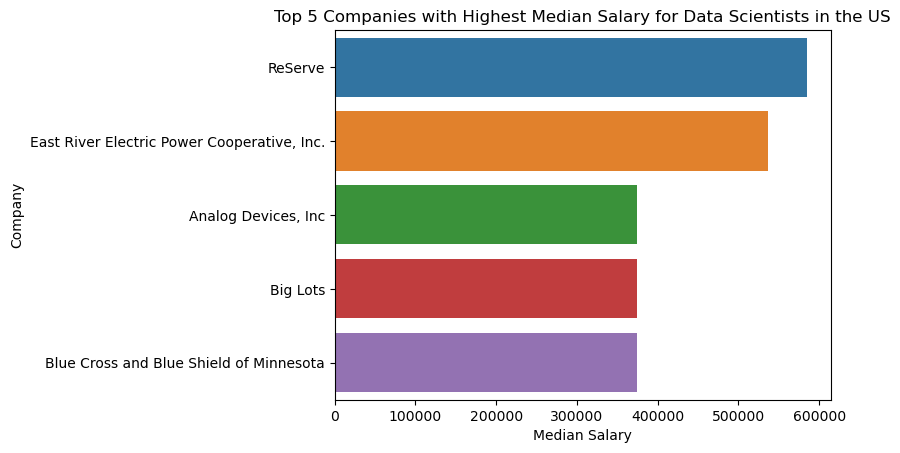

In [32]:
df_DS_US = df[(df['job_title_short']=='Data Scientist') & (df['job_country']=='United States')].copy().dropna(subset=['salary_year_avg'])
top_companies = df_DS_US.groupby('company_name')['salary_year_avg'].median()
top_companies = top_companies.nlargest(5).reset_index(name='median_salary')
sns.barplot(data=top_companies, x='median_salary', y='company_name', hue='company_name', palette='tab10')
plt.xlabel('Median Salary')
plt.ylabel('Company')
plt.title('Top 5 Companies with Highest Median Salary for Data Scientists in the US')
plt.show()

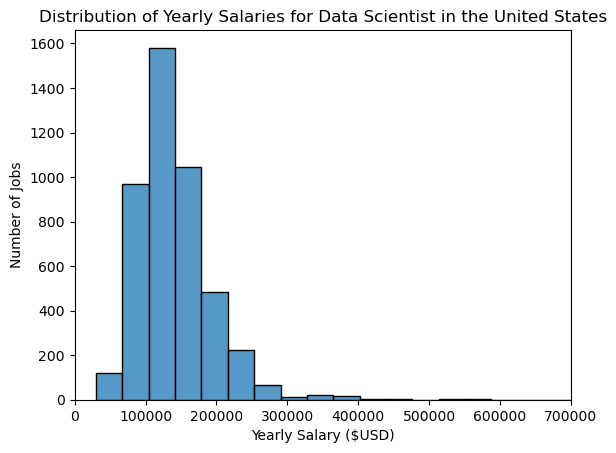

In [45]:
sns.histplot(df_DS_US['salary_year_avg'], bins=25)
plt.xlim(0, 700000)
plt.title('Distribution of Yearly Salaries for Data Scientist in the United States')
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel('Number of Jobs')
plt.show()

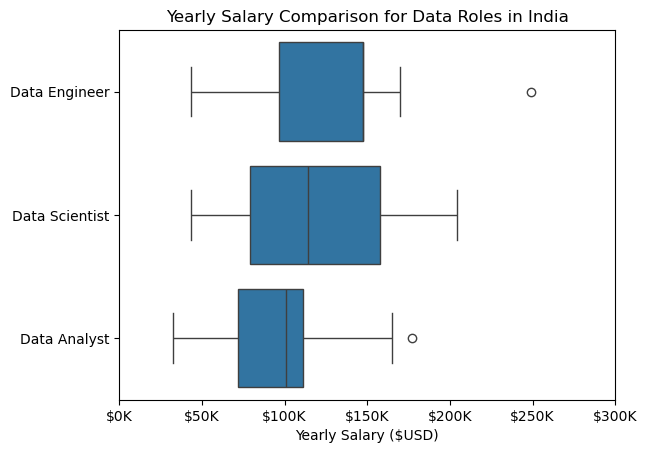

In [56]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']
df_India = df[(df['job_title_short'].isin(job_titles)) & (df['job_country']=='India')].copy().dropna(subset=['salary_year_avg'])

sns.boxplot(df_India, x='salary_year_avg', y='job_title_short')
plt.xlim(0, 300000)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${x/1000:,.0f}K'))
plt.title('Yearly Salary Comparison for Data Roles in India')
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel('')
plt.show()

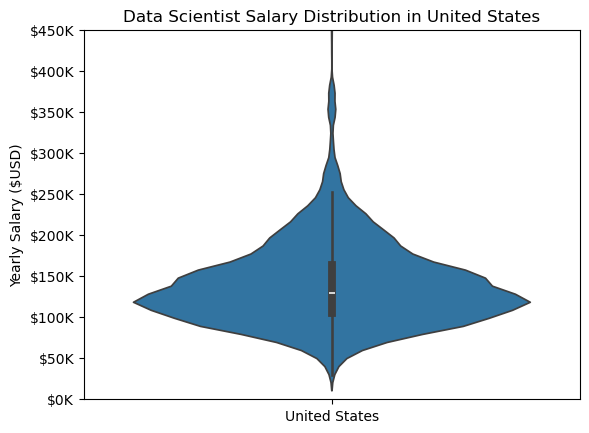

In [69]:
sns.violinplot(df_DS_US, x='job_country', y='salary_year_avg')
plt.ylim(0, 450000)
plt.title('Data Scientist Salary Distribution in United States')
plt.ylabel('Yearly Salary ($USD)')
plt.xlabel('')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${y/1000:,.0f}K'))